# 02 目标泄漏检测

**要回答的问题**：目标变量 `Logistics_Delay` 能不能被其他字段完全复现？

**为什么这么问**：如果特征里已经包含了答案，那么任何模型都会得到虚高的准确率。
这种错误叫**目标泄漏（target leakage）**，是实际建模中最常见、也最致命的错误之一。

**方法**：遍历所有低基数分类字段，检查每个取值是否唯一对应一个目标值；
单字段不行，再看两两组合。

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 从 notebooks/ 启动，因此父目录就是项目根目录
DATA = Path.cwd().parent / 'data' / 'raw' / 'smart_logistics_dataset.csv'
df = pd.read_csv(DATA, keep_default_na=False, na_values=[''])

print(f'{len(df)} 行 × {df.shape[1]} 列')
print('目标变量取值：', sorted(df['Logistics_Delay'].unique().tolist()))


1000 行 × 16 列
目标变量取值： [0, 1]


## 交叉表证据：为什么这是泄漏，而不是"强相关"

把所有 (路况, 运输状态) 组合与延迟做交叉表。
**如果每个格子里只有一种结果、一个反例都没有**，说明目标变量不是独立观测到的，
而是这些字段的一个确定性函数——这才是泄漏的判定依据。

In [2]:
# =====================================================================
# 目标泄漏检测（target leakage）
#
# 要回答的问题：Logistics_Delay 能否被其他字段完全复现？
# 为什么这么问：如果特征里包含了答案，任何模型都会得到虚高的准确率。
#              这种错误叫目标泄漏，是实际建模中最常见的致命问题。
# 方法：遍历所有低基数分类字段，检查每个取值是否唯一对应一个目标值；
#      单字段不行再看两两组合。
# =====================================================================


def detect_target_leakage(df, target, max_cardinality=10):
    """找出能单独或两两组合完全决定目标变量的字段组合。

    判据：把所有行按候选字段分组后，如果**每一组**内部目标变量的
    唯一值个数都只有 1 个，说明该字段（组合）能完全决定目标 → 泄漏。
    """
    from itertools import combinations

    candidates = [c for c in df.columns
                  if c != target and df[c].nunique() <= max_cardinality]
    findings = []

    for col in candidates:
        nun = df.groupby(col, observed=True)[target].nunique()
        if (nun == 1).all():
            findings.append({'columns': [col], 'n_groups': int(len(nun))})

    for a, b in combinations(candidates, 2):
        nun = df.groupby([a, b], observed=True)[target].nunique()
        if (nun == 1).all():
            findings.append({'columns': [a, b], 'n_groups': int(len(nun))})

    return findings


TARGET = 'Logistics_Delay'
print('候选字段（取值数 ≤ 10）：')
cands = [c for c in df.columns if c != TARGET and df[c].nunique() <= 10]
for c in cands:
    print(f'  {c:26s} nunique={df[c].nunique()}')

print()
hits = detect_target_leakage(df, TARGET)
if hits:
    print(f'检出 {len(hits)} 组可完全复现目标变量的字段组合：')
    for h in hits:
        print(f"  {h['columns']}  （{h['n_groups']} 个分组，每组目标值唯一）")
else:
    print('未检出目标泄漏。')


候选字段（取值数 ≤ 10）：
  Asset_ID                   nunique=10
  Shipment_Status            nunique=3
  Traffic_Status             nunique=3
  User_Purchase_Frequency    nunique=10
  Logistics_Delay_Reason     nunique=4

检出 1 组可完全复现目标变量的字段组合：
  ['Shipment_Status', 'Traffic_Status']  （9 个分组，每组目标值唯一）


In [3]:
# =====================================================================
# 验证泄漏公式，并计算复现命中率
# =====================================================================

# 用检出的字段组合构造规则
pred = ((df['Shipment_Status'] == 'Delayed') |
        (df['Traffic_Status'] == 'Heavy')).astype(int)

hit_rate = (pred == df['Logistics_Delay']).mean()
print(f'复现命中率：{int((pred == df["Logistics_Delay"]).sum())}/{len(df)} '
      f'= {hit_rate:.4f}')

# 拆开看两个条件各自的贡献
cond_status = df['Shipment_Status'] == 'Delayed'
cond_traffic = df['Traffic_Status'] == 'Heavy'
print()
print(f"Shipment_Status == 'Delayed' : {int(cond_status.sum()):>4} 行，"
      f"其中延迟 {int(df.loc[cond_status, TARGET].sum())} 行")
print(f"Traffic_Status  == 'Heavy'   : {int(cond_traffic.sum()):>4} 行，"
      f"其中延迟 {int(df.loc[cond_traffic, TARGET].sum())} 行")
print(f'两个条件重叠              : {int((cond_status & cond_traffic).sum()):>4} 行')
print()
print('=> 目标变量不是独立观测到的，而是另外两列的一个布尔函数。')
print('=> 这意味着本数据集存在数据泄漏，不能用于延迟预测建模。')


复现命中率：1000/1000 = 1.0000

Shipment_Status == 'Delayed' :  350 行，其中延迟 350 行
Traffic_Status  == 'Heavy'   :  327 行，其中延迟 327 行
两个条件重叠              :  111 行

=> 目标变量不是独立观测到的，而是另外两列的一个布尔函数。
=> 这意味着本数据集存在数据泄漏，不能用于延迟预测建模。


Traffic_Status × Shipment_Status × Logistics_Delay：
Logistics_Delay                   0    1   All
Traffic_Status Shipment_Status                
Clear          Delayed            0  115   115
               Delivered        100    0   100
               In Transit       113    0   113
Detour         Delayed            0  124   124
               Delivered        120    0   120
               In Transit       101    0   101
Heavy          Delayed            0  111   111
               Delivered          0  118   118
               In Transit         0   98    98
All                             434  566  1000

关键观察：每个格子里只有一种结果，没有一格同时出现 0 和 1。
真实业务数据一定会出现反例（路况差但准时、路况好却延迟），
一个反例都没有，正是"数据由公式生成"的最硬证据。


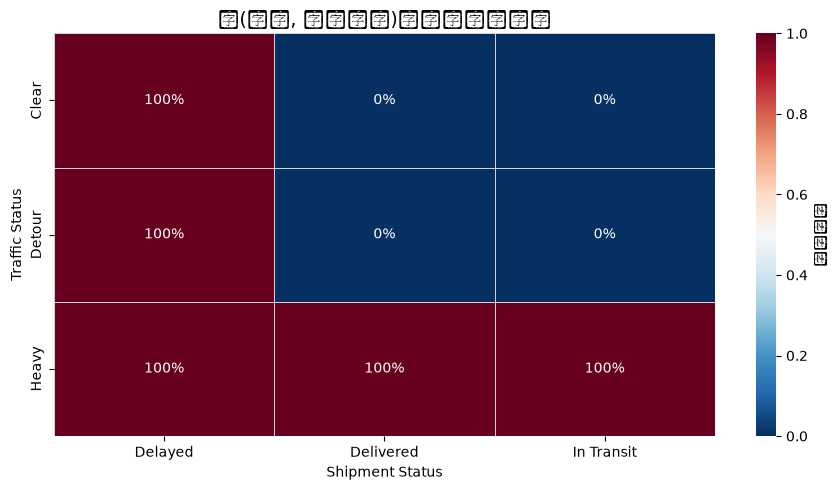

In [4]:
# =====================================================================
# 交叉表证据：为什么说这是泄漏而不是"强相关"
# =====================================================================

evidence = pd.crosstab(
    [df['Traffic_Status'], df['Shipment_Status']],
    df['Logistics_Delay'],
    margins=True,
)
print('Traffic_Status × Shipment_Status × Logistics_Delay：')
print(evidence)

print()
print('关键观察：每个格子里只有一种结果，没有一格同时出现 0 和 1。')
print('真实业务数据一定会出现反例（路况差但准时、路况好却延迟），')
print('一个反例都没有，正是"数据由公式生成"的最硬证据。')

# 用热力图呈现：颜色越接近 0% 或 100%，越说明是确定性关系
rate = df.groupby(['Traffic_Status', 'Shipment_Status'],
                  observed=True)[TARGET].mean().unstack()

plt.figure(figsize=(9, 5))
sns.heatmap(rate, annot=True, fmt='.0%', cmap='RdBu_r', vmin=0, vmax=1,
            linewidths=0.5, linecolor='lightgrey', cbar_kws={'label': '延迟比例'})
plt.title('各(路况, 运输状态)组合的延迟比例', fontsize=14)
plt.xlabel('Shipment Status')
plt.ylabel('Traffic Status')
plt.tight_layout()
plt.show()


In [5]:
from scipy.stats import chi2_contingency

# --- 创建二元交通状态变量 ---

# 将 Clear 和 Detour（Traffic_Status）合并为“Not Heavy”，以便比较。
df['Traffic_Heavy_Status'] = np.where(
    df['Traffic_Status'] == 'Heavy',
    'Heavy',
    'Not Heavy'
)

# --- 创建列联表（观测频数）---

# 行：拥堵（Heavy）与非拥堵（Not Heavy）。列：物流延迟（Logistics_Delay）（0：无延迟，1：延迟）。
contingency_table = pd.crosstab(
    df['Traffic_Heavy_Status'],
    df['Logistics_Delay']
)

# 转换为 NumPy 数组，以供 chi2_contingency（卡方列联表检验）使用。
observed_table = contingency_table.values

# --- 进行独立性卡方检验 ---

chi2, p_value, degrees_of_freedom, expected_table = chi2_contingency(observed_table)

# --- 准备输出与结果解读 ---

alpha = 0.05

# 计算延迟比例，以解读效应的方向。
prop_heavy = contingency_table.loc['Heavy', 1] / contingency_table.loc['Heavy'].sum()
prop_not_heavy = contingency_table.loc['Not Heavy', 1] / contingency_table.loc['Not Heavy'].sum()

# 结论陈述。
if p_value < alpha:
    conclusion = (f"Reject the Null Hypothesis (H_0): There is a statistically significant "
                  f"association between the traffic status being 'Heavy' and the occurrence "
                  f"of a Logistics Delay.")
else:
    conclusion = (f"Fail to Reject the Null Hypothesis (H_0): There is NO statistically significant "
                  f"association between the traffic status being 'Heavy' and the occurrence "
                  f"of a Logistics Delay.")

# --- 显示汇总 ---

print("--- Chi-Squared Test: Traffic Status ('Heavy') vs. Logistics Delay ---")
print("\nObserved Contingency Table (Counts):")
print(contingency_table)

print(f"\nChi-Squared Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.5f}")
print(f"Degrees of Freedom: {degrees_of_freedom}")
print(f"Significance Level (alpha): {alpha}")
print(f"Proportion of Delays in Heavy Traffic: {prop_heavy:.2%}")
print(f"Proportion of Delays in Non-Heavy Traffic: {prop_not_heavy:.2%}")

print("\nConclusion:")
print(conclusion)

--- Chi-Squared Test: Traffic Status ('Heavy') vs. Logistics Delay ---

Observed Contingency Table (Counts):
Logistics_Delay         0    1
Traffic_Heavy_Status          
Heavy                   0  327
Not Heavy             434  239

Chi-Squared Statistic: 369.9478
P-value: 0.00000
Degrees of Freedom: 1
Significance Level (alpha): 0.05
Proportion of Delays in Heavy Traffic: 100.00%
Proportion of Delays in Non-Heavy Traffic: 35.51%

Conclusion:
Reject the Null Hypothesis (H_0): There is a statistically significant association between the traffic status being 'Heavy' and the occurrence of a Logistics Delay.


## 附：路况 Heavy 与延迟的卡方检验

（沿用源项目的检验，作为对照。）
注意：这个检验只能说明"两者相关"，不能说明"谁导致谁"。
真正的结论来自本 notebook 的泄漏检测——**Heavy 组延迟率恰好是 100%，是恒等关系而非因果关系**。